# EDA - Credit Score

Business Problem:

> "Will this customer default on their credit line in the next 2 years?"

This is purely exploratory. No transforms, no writes.

- How severe is the class imbalance? (determines scale_pos_weight value for XGBoost)
- Which features have outliers so extreme they're data errors vs. legitimate? (determines capping thresholds)
- Is missingness in monthly_income random or correlated with default? (determines imputation strategy)
- Are there any features with near-zero variance or perfect correlation? (determines if we drop anything)


Install packages

In [1]:
!uv pip install -q \
        pandas==3.0.1 \
        pyarrow==23.0.1 \
        boto3==1.42.68 \
        matplotlib==3.10.8 \
        seaborn==0.13.2 \
        scipy==1.17.1

Check package versions

In [2]:
!uv pip freeze | grep -E "pandas|pyarrow|boto3|matplotlib|seaborn|scipy"

boto3==1.42.68
matplotlib==3.10.8
pandas==3.0.1
pyarrow==23.0.1
scipy==1.17.1
seaborn==0.13.2


Import packages

In [3]:
import io
import warnings

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [4]:
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.expand_frame_repr", False)

sns.set_style("darkgrid")
sns.set_theme(style="darkgrid")

S3_ENDPOINT = "http://localstack:4566"
BUCKET = "data-lake"
PREFIX = "silver/credit_risk/cleaned/ingestion_date=2026-03-14/"

Load Dataset

In [5]:
s3_client = boto3.client(
    "s3",
)


response = s3_client.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX)
parquet_keys = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".parquet")
]


dfs = []

for key in parquet_keys:
    obj = s3_client.get_object(Bucket=BUCKET, Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(obj["Body"].read())))

df = pd.concat(dfs, ignore_index=True)

df.head()

,serious_dlqin2yrs,revolving_utilization_of_unsecured_lines,age,number_of_time30_59_days_past_due_not_worse,debt_ratio,monthly_income,number_of_open_credit_lines_and_loans,number_of_times90_days_late,number_real_estate_loans_or_lines,number_of_time60_89_days_past_due_not_worse,number_of_dependents
0,1,0.8804,43,0,0.4613,7523.0000,6,0,1,0,1.0000
1,0,0.0224,72,0,1004.0000,NaN,6,0,1,0,0.0000
2,0,0.5589,49,0,0.4871,9077.0000,18,0,1,0,3.0000
3,0,0.1458,61,0,1211.0000,NaN,8,0,1,0,0.0000
4,0,0.2074,54,0,0.3909,8685.0000,11,0,1,0,2.0000


Define target & features

In [6]:
df = df.drop(columns=["ingestion_date"], errors="ignore")

TARGET = "serious_dlqin2yrs"
FEATURES = [c for c in df.columns if c != TARGET]

In [7]:
print(f"Shape: {df.shape}\n")
print(f"\nTarget: {TARGET}\n")
print(f"Features: {FEATURES}\n")

Shape: (149391, 11)


Target: serious_dlqin2yrs

Features: ['revolving_utilization_of_unsecured_lines', 'age', 'number_of_time30_59_days_past_due_not_worse', 'debt_ratio', 'monthly_income', 'number_of_open_credit_lines_and_loans', 'number_of_times90_days_late', 'number_real_estate_loans_or_lines', 'number_of_time60_89_days_past_due_not_worse', 'number_of_dependents']



## Target distribution

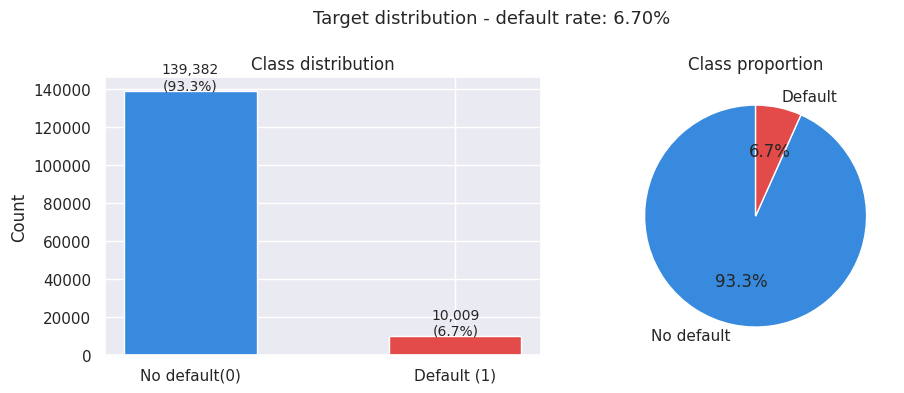


Imbalance Ratio (neg/pos): 13.93
Use scale_pos_weight=13.9 for XGBoost/LightGBM


In [8]:
counts = df[TARGET].value_counts()

rate = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ["No default(0)", "Default (1)"],
    counts.values,
    color=["#378ADD", "#E24B4A"],
    width=0.5,
)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")

label_margin_offset = 500

for index, value in enumerate(counts.values):
    axes[0].text(
        index,
        value + label_margin_offset,
        f"{value:,}\n({value/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10,
    )

axes[1].pie(
    counts.values,
    labels=["No default", "Default"],
    autopct="%1.1f%%",
    colors=["#378ADD", "#E24B4A"],
    startangle=90,
)
axes[1].set_title("Class proportion")


plt.suptitle(f"Target distribution - default rate: {rate:.2f}%", fontsize=13)
plt.tight_layout()


plt.show()

scale_pos_weight = counts[0] / counts[1]
print(f"\nImbalance Ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"Use scale_pos_weight={scale_pos_weight:.1f} for XGBoost/LightGBM")

## Missingness audit

In [9]:
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)

print("=== Missing values ===")
for col in miss.index:
    print(f" {col:<45} {miss[col]:>6} ({miss_pct[col]:.2f}%)")

print("\n=== Is missingness correlated to default? ===")
for col in miss.index:
    mask = df[col].isnull()
    default_missing = df.loc[mask, TARGET].mean()
    default_present = df.loc[~mask, TARGET].mean()
    print(f" {col}")
    print(f"  default rate when MISSING: {default_missing:.4f}")
    print(f"  default rate when PRESENT: {default_present:.4f}")
    print(f"""
        → {
        'INFORMATIVE missingness — consider missing indicator feature'
        if abs(default_missing - default_present) > 0.01
        else 'likely MCAR — simple median imputation is fine'}
        """)

=== Missing values ===
 monthly_income                                 29221 (19.56%)
 number_of_dependents                            3828 (2.56%)

=== Is missingness correlated to default? ===
 monthly_income
  default rate when MISSING: 0.0566
  default rate when PRESENT: 0.0695

        → INFORMATIVE missingness — consider missing indicator feature
        
 number_of_dependents
  default rate when MISSING: 0.0465
  default rate when PRESENT: 0.0675

        → INFORMATIVE missingness — consider missing indicator feature
        


## Feature distribution & outlier audit

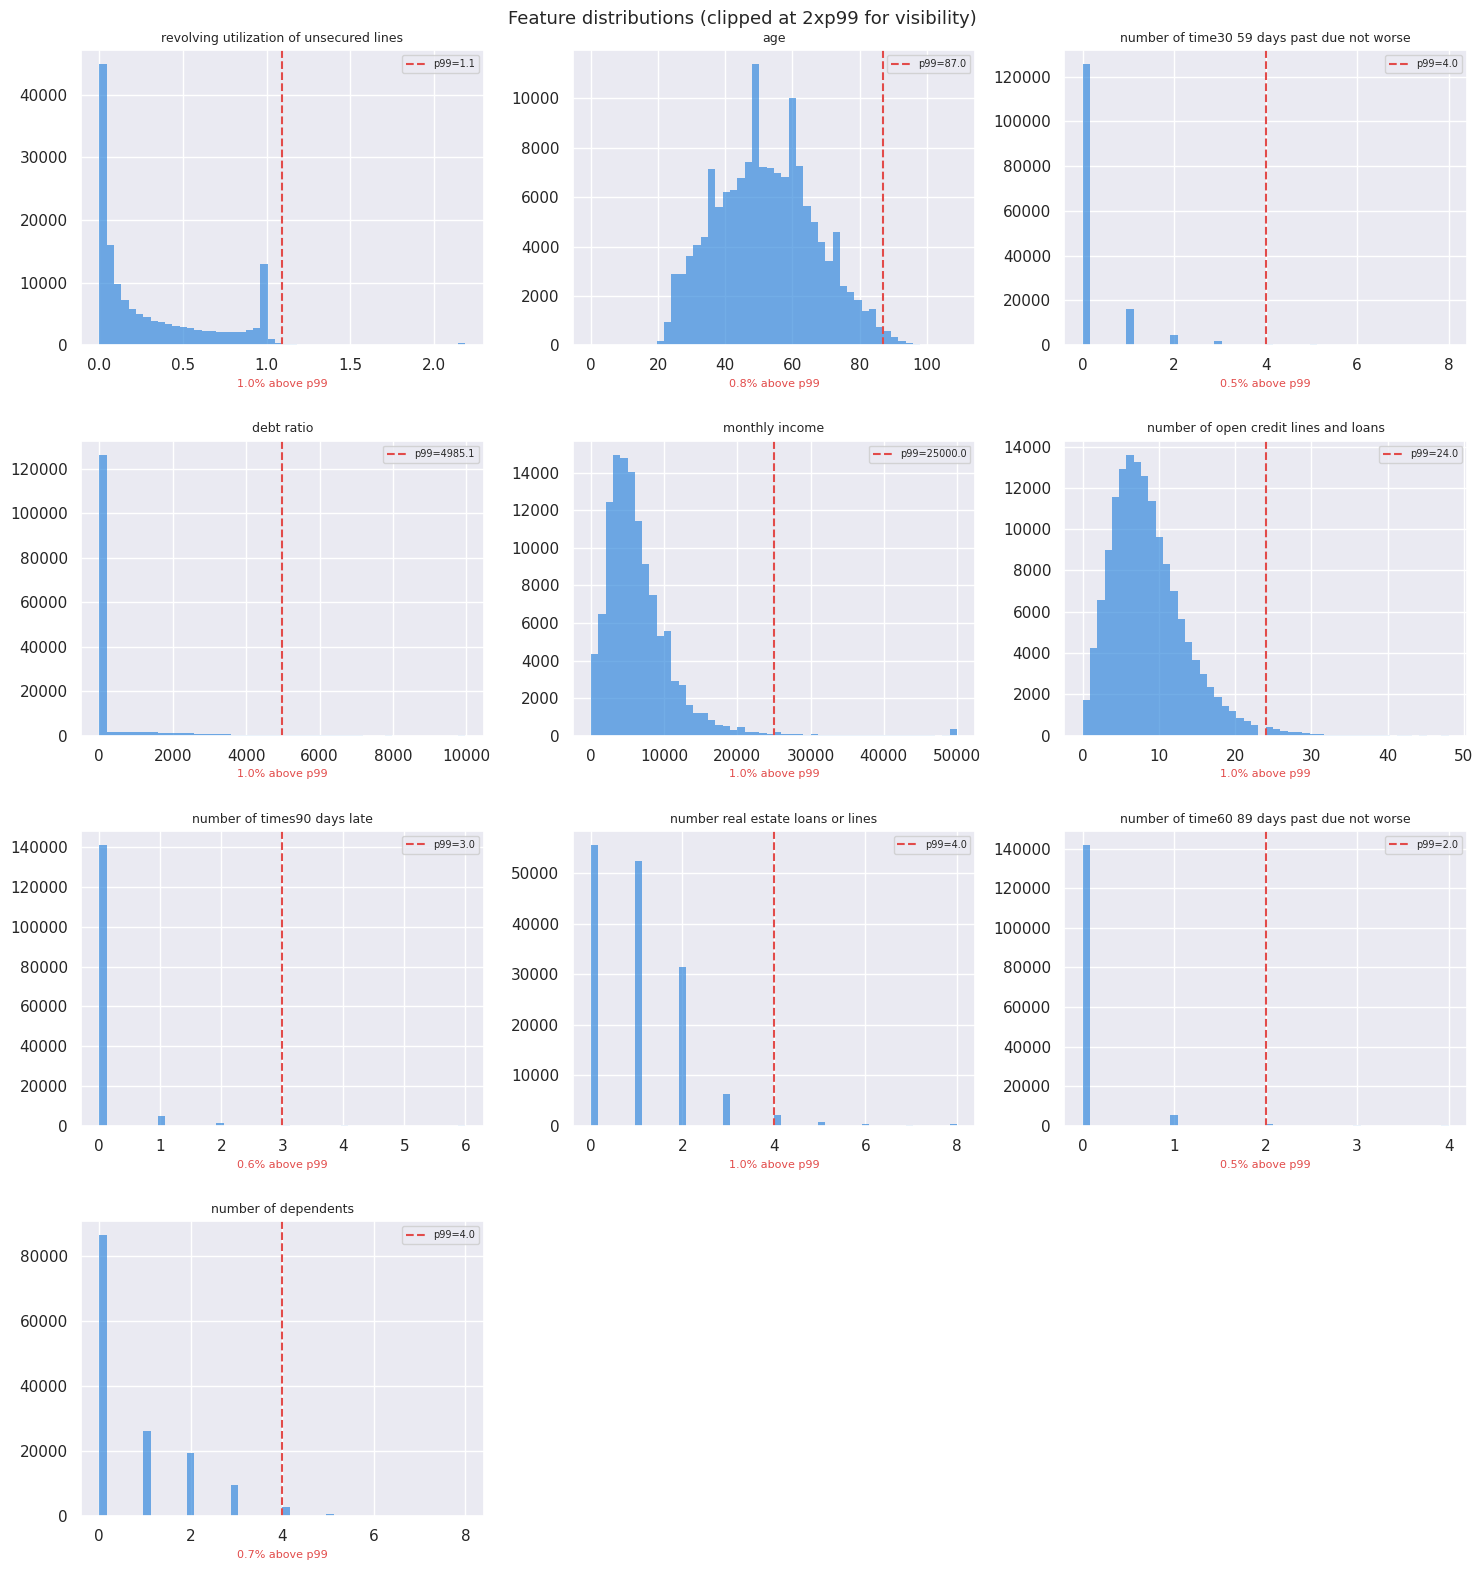


=== Outlier Summary (Values above p99) ===
                                                 1%        99%          max  % > p99
revolving_utilization_of_unsecured_lines     0.0000     1.0900   50708.0000   1.0000
age                                         24.0000    87.0000     109.0000   0.8400
number_of_time30_59_days_past_due_not_worse  0.0000     4.0000      98.0000   0.5400
debt_ratio                                   0.0000  4985.1000  329664.0000   1.0000
monthly_income                               0.0000 25000.0000 3008750.0000   0.7800
number_of_open_credit_lines_and_loans        0.0000    24.0000      58.0000   0.9900
number_of_times90_days_late                  0.0000     3.0000      98.0000   0.5500
number_real_estate_loans_or_lines            0.0000     4.0000      54.0000   0.9900
number_of_time60_89_days_past_due_not_worse  0.0000     2.0000      98.0000   0.4800
number_of_dependents                         0.0000     4.0000      20.0000   0.6600


In [10]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for index, col in enumerate(FEATURES):
    ax = axes[index]
    data = df[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)

    ax.hist(
        data.clip(upper=p99 * 2),
        bins=50,
        color="#378ADD",
        alpha=0.7,
        edgecolor="none",
    )
    ax.axvline(
        p99,
        color="#E24B4A",
        linewidth=1.5,
        linestyle="--",
        label=f"p99={p99:.1f}",
    )
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.legend(fontsize=7)

    extreme_pct = (data > p99).sum() / len(data) * 100
    if extreme_pct > 0:
        ax.set_xlabel(
            f"{extreme_pct:.1f}% above p99",
            fontsize=8,
            color="#E24B4A",
        )

for j in range(index + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions (clipped at 2xp99 for visibility)", fontsize=13)
plt.tight_layout(h_pad=2.0)
plt.show()

summary = df[FEATURES].describe(percentiles=[0.01, 0.99]).T
summary["% > p99"] = (df[FEATURES] > summary["99%"]).mean() * 100

print("\n=== Outlier Summary (Values above p99) ===")
print(summary[["1%", "99%", "max", "% > p99"]].round(2))